=== ε Sensitivity Analysis ===


  ε=1e-05: κ = 0.032769


  ε=1e-04: κ = 0.032494


  ε=5e-04: κ = 0.032572


  ε=1e-03: κ = 0.033048


  ε=5e-03: κ = 0.032457


  ε=1e-02: κ = 0.043522


  ε=5e-02: κ = 0.145325


fig8b done


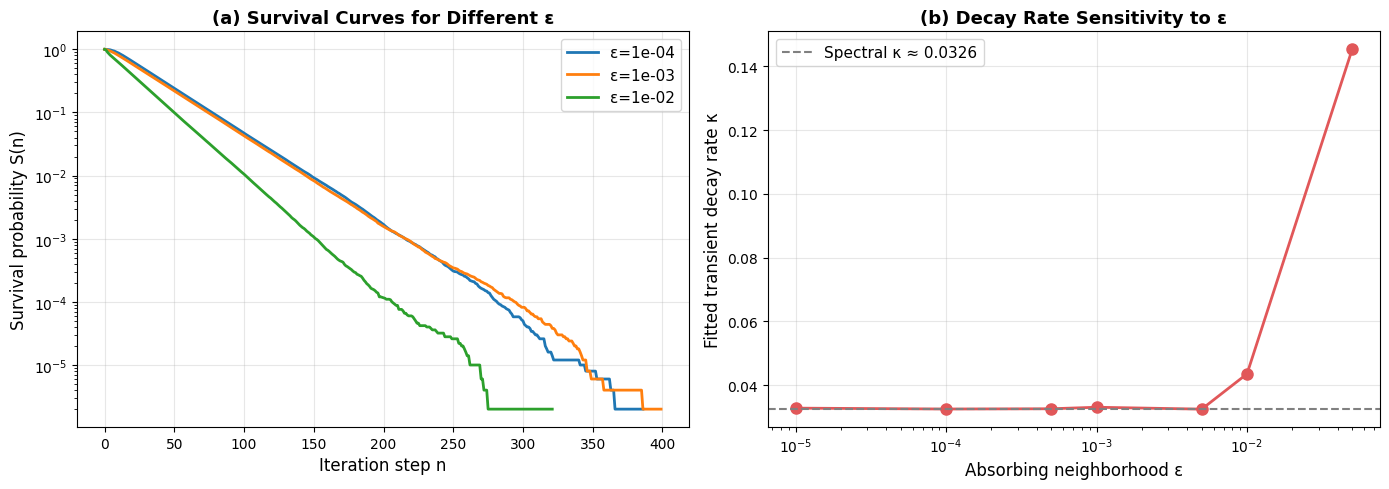

In [1]:
"""Epsilon sensitivity analysis for transient decay rate."""
import numpy as np
import matplotlib

import matplotlib.pyplot as plt

MU = 1.7548776662466927
TARGETS = np.array([0.0, 1.0, 1.0 - MU])

def survival_curve(mu, n_samples, max_steps, eps_absorb):
    x = np.random.uniform(-1, 1, n_samples)
    survival = np.zeros(max_steps)
    active = np.ones(n_samples, dtype=bool)
    for t in range(max_steps):
        survival[t] = np.sum(active)
        if not np.any(active): break
        d = np.min(np.abs(x[active, None] - TARGETS[None, :]), axis=1)
        converged = d < eps_absorb
        idx = np.where(active)[0]
        active[idx[converged]] = False
        x[active] = 1.0 - mu * x[active]**2
    return survival / n_samples

def fit_decay_rate(surv, t_start=20, t_end=200):
    t = np.arange(len(surv))
    mask = (t >= t_start) & (t <= t_end) & (surv > 1e-6)
    if np.sum(mask) < 10: return np.nan
    log_s = np.log(surv[mask])
    t_m = t[mask]
    slope, _, _, _, _ = np.polyfit(t_m, log_s, 1, full=False, cov=False), 0, 0, 0, 0
    coeffs = np.polyfit(t_m, log_s, 1)
    return -coeffs[0]

eps_values = [1e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2]
N_SAMPLES = 500000
MAX_STEPS = 400

print("=== ε Sensitivity Analysis ===")
kappas = []
for eps in eps_values:
    surv = survival_curve(MU, N_SAMPLES, MAX_STEPS, eps)
    t = np.arange(len(surv))
    mask = (t >= 20) & (t <= 250) & (surv > 1e-6)
    if np.sum(mask) < 10:
        kappas.append(np.nan)
        print(f"  ε={eps:.0e}: insufficient data")
        continue
    coeffs = np.polyfit(t[mask], np.log(surv[mask]), 1)
    kappa = -coeffs[0]
    kappas.append(kappa)
    print(f"  ε={eps:.0e}: κ = {kappa:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Survival curves for different ε
for eps in [1e-4, 1e-3, 1e-2]:
    surv = survival_curve(MU, N_SAMPLES, MAX_STEPS, eps)
    valid = surv > 1e-6
    axes[0].semilogy(np.arange(len(surv))[valid], surv[valid], label=f'ε={eps:.0e}', linewidth=2)
axes[0].set_xlabel('Iteration step n', fontsize=12)
axes[0].set_ylabel('Survival probability S(n)', fontsize=12)
axes[0].set_title('(a) Survival Curves for Different ε', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# (b) κ vs ε
valid_k = [(e, k) for e, k in zip(eps_values, kappas) if not np.isnan(k)]
if valid_k:
    es, ks = zip(*valid_k)
    axes[1].semilogx(es, ks, 'o-', color='#E15759', markersize=8, linewidth=2)
    axes[1].axhline(y=0.0326, color='gray', linestyle='--', label='Spectral κ ≈ 0.0326')
    axes[1].set_xlabel('Absorbing neighborhood ε', fontsize=12)
    axes[1].set_ylabel('Fitted transient decay rate κ', fontsize=12)
    axes[1].set_title('(b) Decay Rate Sensitivity to ε', fontsize=13, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig8b.png', dpi=300)
print("fig8b done")
